# 07. Wind Vector Feature Lab: U/V에서 풍속·순환 풍향으로

> 작성일: 2026-07-17 KST  
> 연구 질문: 채택된 expanded spatial 기준선에 물리적으로 해석 가능한 풍속·meteorological wind-from 순환 피처를 더하면 동일한 2024 time holdout에서 개선되는가?

이 노트북은 구현 후 덧붙인 보고서가 아니라 RED 테스트와 동시에 골격을 먼저 고정한 실험 기록이다. 원시 데이터는 읽기 전용이며 모델·registry·submission·outputs 파일을 만들지 않는다. Group 3 결측 label은 0으로 대체하지 않고 target별 non-null mask를 사용한다. actual은 원본을 유지하고 prediction만 capacity 범위로 clip한다.

## 벤치마킹 융합표와 물리 범위

| 근거 | 이어받는 원칙 | 이번 적용 |
|---|---|---|
| 06 weather lab | expanded spatial 271개, 2024 holdout, train-fit median | 유일한 비교군으로 유지 |
| ECMWF U/V 규약 | U는 동향, V는 북향; 풍향은 불어오는 방향 | speed와 wind-from sin/cos 공식 고정 |
| NOAA/NWS 풍향 정의 | 풍향은 바람이 불어오는 방향 | 북=0°, 동=90° 사분면 테스트 |
| KMA LDAPS 변수표 | X/Y BLWS는 surface & BL wind stress, 단위 N/m² | 5m X/Y를 풍속 pair에서 제외 |
| 원시 데이터 감사 | 50m max/min은 성분별 독립 극값 | 동시 벡터 근거가 없어 제외 |

공식 참고: [ECMWF U/V convention](https://confluence.ecmwf.int/spaces/FCST/pages/111155337/What%2Bis%2Bthe%2Bdirection%2Bconvention%2Bfor%2Bthe%2BU%2Band%2BV%2Bcomponents%2Bof%2Bwinds), [ECMWF conversion formula](https://confluence.ecmwf.int/plugins/viewsource/viewpagesrc.action?pageId=402631619), [NOAA wind direction](https://forecast.weather.gov/glossary.php?word=WIND+DIRECTION), [KMA LDAPS variables](https://datawiki.kma.go.kr/doku.php?id=%EC%88%98%EC%B9%98%EB%AA%A8%EB%8D%B8%3A%EB%8B%A8%EC%A4%91%EA%B8%B0%EB%AA%A8%EB%8D%B8%3Anwp_header_um_l015_unis).

Primary pair는 LDAPS 10m와 GFS 10/80/100m 네 쌍이다. GFS PBL·850/700/500hPa는 유효한 U/V지만 허브 높이 근처 효과와 상층 문맥을 섞지 않기 위해 후속 후보로 남긴다. LDAPS는 Lambert 격자에서 원자료 회전 여부가 명시되지 않아 방향을 true-north로 단정하지 않고 데이터 좌표계 기반 순환 성분이라는 한계를 명시한다. speed는 좌표 회전에 불변이다.

## 전문가 방법론: 5단계와 증거 사다리

1. 데이터 파악: source 계약, 선택·제외 pair의 물리 의미, 결측·비유한·calm·풍속 범위를 잠근다.
2. 데이터 전처리/가공: grid 행에서 먼저 파생한 뒤 공간 집계하며 공식, threshold, NaN, 이름·순서, imputer fit 범위를 잠근다.
3. 속성 탐색: 풍속 분포와 원형 평균 resultant를 확인하되 단순 상관만으로 채택하지 않는다.
4. 시각화: 풍속 envelope와 순환 좌표가 실제 시간·공간 변화를 담는지 확인한다.
5. 해석과 의사결정: 동일 RF·seed·split·mask·metric·clipping에서 271개와 319개만 비교한다.

앞 단계 계약이 실패하면 뒤 단계 성능을 의사결정 근거로 승격하지 않는다.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
  PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
  sys.path.insert(0, str(SRC_DIR))

from baram.baseline import (
  OFFICIAL_RF_PARAMS,
  calendar_features,
  predict_random_forest_baseline,
  train_random_forest_baseline,
)
from baram.features.weather_grid import (
  SPATIAL_STATISTICS,
  build_weather_feature_pair,
  fit_train_median_imputer,
)
from baram.features.wind_vector import (
  DEFAULT_CALM_SPEED_THRESHOLD,
  DEFAULT_WIND_VECTOR_SPECS,
  derive_wind_vector_features,
)
from baram.metrics import CAPACITY_KWH, TARGET_COLS, metric

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "open"
ARTIFACT_ROOTS = [
  PROJECT_ROOT / "outputs",
  PROJECT_ROOT / "submissions",
  PROJECT_ROOT / "models",
]
GUARDED_ARTIFACT_PATTERNS = [
  "*.pkl",
  "*.pickle",
  "*.joblib",
  "*registry*.csv",
  "*submission*.csv",
]

def snapshotArtifactFiles():
  return sorted(
    str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
    for root in ARTIFACT_ROOTS
    if root.exists()
    for path in root.rglob("*")
    if path.is_file() and path.name != ".gitkeep"
  )

def snapshotGuardedArtifacts():
  guarded = set()
  for pattern in GUARDED_ARTIFACT_PATTERNS:
    for path in PROJECT_ROOT.rglob(pattern):
      relativePath = str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
      if path.is_file() and not relativePath.startswith("data/raw/open/"):
        guarded.add(relativePath)
  return sorted(guarded)

artifactFilesBefore = snapshotArtifactFiles()
guardedArtifactsBefore = snapshotGuardedArtifacts()
pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")
display({
  "project_root": str(PROJECT_ROOT),
  "python": sys.version.split()[0],
  "raw_read_only": True,
  "calm_speed_threshold": DEFAULT_CALM_SPEED_THRESHOLD,
  "rf_params": OFFICIAL_RF_PARAMS,
  "artifact_files_before": artifactFilesBefore,
  "guarded_artifacts_before": guardedArtifactsBefore,
})

{'project_root': 'C:\\Users\\kik32\\workspace\\Dacon\\2026-BARAM-Wind-Power-Prediction-AI-Competition',
 'python': '3.12.13',
 'raw_read_only': True,
 'calm_speed_threshold': 1e-06,
 'rf_params': {'n_estimators': 120,
  'max_depth': 14,
  'min_samples_leaf': 8,
  'max_features': 'sqrt',
  'random_state': 42,
  'n_jobs': -1},
 'artifact_files_before': [],
 'guarded_artifacts_before': []}

## TDD RED 실행 증거

구현 전에 필수 U/V 누락, 문자열·bool·complex dtype, 기존 출력명 충돌, 중복 규격, 음수·NaN·무한·bool·문자 threshold, 3-4-5 공식, N/E/S/W 사분면, calm, 결측 전파, 입력 불변·정렬, stress·성분 극값 제외, 미지원 source를 실패 사례로 고정했다.

- RED 명령: python -m pytest tests/test_wind_vector_features.py -q
- RED 결과: **18 failed in 4.52s**
- 실패 원인: 공개 API 스텁이 명시적 NotImplementedError를 내도록 하여 신규 계약 18건이 모두 실제 RED임을 확인했다.

In [2]:
redEvidence = pd.DataFrame([
  ("필수 component", "U/V 하나라도 없으면 즉시 실패", 1),
  ("dtype", "문자·bool·complex 거부", 3),
  ("이름 계약", "기존 출력명·중복 spec 충돌", 2),
  ("calm threshold", "음수·NaN·무한·bool·문자 거부", 5),
  ("물리 공식", "3-4-5와 N/E/S/W wind-from", 2),
  ("calm·결측", "방향 NaN과 세 값 결측 전파", 2),
  ("불변·범위", "입력 불변·정렬·제외 whitelist·source", 3),
], columns=["계약군", "RED 기대", "수집 사례"])
display(redEvidence)
print("RED: python -m pytest tests/test_wind_vector_features.py -q")
print("결과: 18 failed in 4.52s")

,계약군,RED 기대,수집 사례
0,필수 component,U/V 하나라도 없으면 즉시 실패,1
1,dtype,문자·bool·complex 거부,3
2,이름 계약,기존 출력명·중복 spec 충돌,2
3,calm threshold,음수·NaN·무한·bool·문자 거부,5
4,물리 공식,3-4-5와 N/E/S/W wind-from,2
5,calm·결측,방향 NaN과 세 값 결측 전파,2
6,불변·범위,입력 불변·정렬·제외 whitelist·source,3


RED: python -m pytest tests/test_wind_vector_features.py -q
결과: 18 failed in 4.52s


## 1단계. 데이터 파악: pair를 만들기 전에 의미를 잠근다

네 weather 파일의 행 수·forecast 수·grid·lead·cutoff·train/test schema를 다시 확인한다. 선택한 네 U/V pair는 결측·비유한값·정확한 calm과 speed 범위를 전수 프로파일링한다. 이 단계에서는 raw 값을 수정하거나 결측을 채우지 않는다.

In [3]:
inputPaths = {
  "train_labels": DATA_ROOT / "train" / "train_labels.csv",
  "ldaps_train": DATA_ROOT / "train" / "ldaps_train.csv",
  "gfs_train": DATA_ROOT / "train" / "gfs_train.csv",
  "ldaps_test": DATA_ROOT / "test" / "ldaps_test.csv",
  "gfs_test": DATA_ROOT / "test" / "gfs_test.csv",
  "sample_submission": DATA_ROOT / "sample_submission.csv",
}
frames = {
  name: pd.read_csv(path, encoding="utf-8-sig")
  for name, path in inputPaths.items()
}
trainLabels = frames["train_labels"].copy()
trainLabels["kst_dtm"] = pd.to_datetime(trainLabels["kst_dtm"], errors="raise")
sampleSubmission = frames["sample_submission"].copy()
sampleSubmission["forecast_kst_dtm"] = pd.to_datetime(
  sampleSubmission["forecast_kst_dtm"], errors="raise"
)
weatherFrames = {
  name: frames[name]
  for name in ["ldaps_train", "gfs_train", "ldaps_test", "gfs_test"]
}

sourceRows = []
for name, frame in weatherFrames.items():
  source = name.split("_")[0]
  forecast = pd.to_datetime(frame["forecast_kst_dtm"], errors="raise")
  available = pd.to_datetime(frame["data_available_kst_dtm"], errors="raise")
  leadHour = (forecast - available).dt.total_seconds().div(3600)
  grouped = pd.DataFrame({
    "forecast": forecast,
    "lead": leadHour,
    "grid_id": frame["grid_id"],
  }).groupby("forecast", sort=True)
  counterpart = frames[f"{source}_{'test' if name.endswith('train') else 'train'}"]
  sourceRows.append({
    "frame": name,
    "rows": len(frame),
    "columns": len(frame.columns),
    "forecast_rows": forecast.nunique(),
    "start_kst": forecast.min(),
    "end_kst": forecast.max(),
    "grid_min": grouped["grid_id"].nunique().min(),
    "grid_max": grouped["grid_id"].nunique().max(),
    "lead_min": leadHour.min(),
    "lead_max": leadHour.max(),
    "inconsistent_lead_forecasts": grouped["lead"].nunique().ne(1).sum(),
    "cutoff_violations": int((available > forecast).sum()),
    "train_test_schema_equal": list(frame.columns) == list(counterpart.columns),
  })
sourceAudit = pd.DataFrame(sourceRows)

pairRows = []
for frameName, frame in weatherFrames.items():
  source = frameName.split("_")[0]
  split = frameName.split("_")[1]
  for spec in DEFAULT_WIND_VECTOR_SPECS[source]:
    uValues = frame[spec.u_column].to_numpy(dtype=float)
    vValues = frame[spec.v_column].to_numpy(dtype=float)
    speed = np.hypot(uValues, vValues)
    missingPair = np.isnan(uValues) | np.isnan(vValues)
    pairRows.append({
      "source": source,
      "split": split,
      "pair": spec.name,
      "rows": len(frame),
      "pair_missing": int(missingPair.sum()),
      "non_finite_non_missing": int(
        ((~np.isfinite(uValues) & ~np.isnan(uValues))
        | (~np.isfinite(vValues) & ~np.isnan(vValues))).sum()
      ),
      "exact_calm": int(((uValues == 0) & (vValues == 0)).sum()),
      "speed_min": np.nanmin(speed),
      "speed_median": np.nanmedian(speed),
      "speed_max": np.nanmax(speed),
    })
pairAudit = pd.DataFrame(pairRows)
excludedPairs = pd.DataFrame([
  {
    "source": "ldaps",
    "candidate": "5m XBLWS/YBLWS",
    "decision": "제외",
    "reason": "KMA 공식상 풍속이 아닌 surface & BL wind stress (N/m²)",
  },
  {
    "source": "ldaps",
    "candidate": "50m U/V max·min",
    "decision": "제외",
    "reason": "성분별 극값의 발생 시각 동시성 근거 없음",
  },
  {
    "source": "gfs",
    "candidate": "PBL·850/700/500hPa U/V",
    "decision": "후속",
    "reason": "허브 높이 효과와 상층 문맥을 분리하기 위한 scope 통제",
  },
])
assert sourceAudit["cutoff_violations"].eq(0).all()
assert sourceAudit["inconsistent_lead_forecasts"].eq(0).all()
assert sourceAudit["train_test_schema_equal"].all()
assert pairAudit["pair_missing"].eq(0).all()
assert pairAudit["non_finite_non_missing"].eq(0).all()
display(sourceAudit)
display(pairAudit)
display(excludedPairs)

,frame,rows,columns,forecast_rows,start_kst,end_kst,grid_min,grid_max,lead_min,lead_max,inconsistent_lead_forecasts,cutoff_violations,train_test_schema_equal
0,ldaps_train,420864,35,26304,2022-01-01 01:00:00,2025-01-01,16,16,12.0,35.0,0,0,True
1,gfs_train,236736,40,26304,2022-01-01 01:00:00,2025-01-01,9,9,12.0,35.0,0,0,True
2,ldaps_test,140160,35,8760,2025-01-01 01:00:00,2026-01-01,16,16,12.0,35.0,0,0,True
3,gfs_test,78840,40,8760,2025-01-01 01:00:00,2026-01-01,9,9,12.0,35.0,0,0,True


,source,split,pair,rows,pair_missing,non_finite_non_missing,exact_calm,speed_min,speed_median,speed_max
0,ldaps,train,10m,420864,0,0,0,0.005627,4.306627,18.412277
1,gfs,train,10m,236736,0,0,0,0.004578,2.182720,25.761482
2,gfs,train,80m,236736,0,0,0,0.002918,2.948741,32.118738
3,gfs,train,100m,236736,0,0,0,0.001271,3.043425,32.895843
4,ldaps,test,10m,140160,0,0,0,0.004388,4.665908,16.261229
5,gfs,test,10m,78840,0,0,0,0.002820,2.303753,21.129396
6,gfs,test,80m,78840,0,0,0,0.007292,3.183121,27.492197
7,gfs,test,100m,78840,0,0,0,0.014647,3.293729,28.109744


,source,candidate,decision,reason
0,ldaps,5m XBLWS/YBLWS,제외,KMA 공식상 풍속이 아닌 surface & BL wind stress (N/m²)
1,ldaps,50m U/V max·min,제외,성분별 극값의 발생 시각 동시성 근거 없음
2,gfs,PBL·850/700/500hPa U/V,후속,허브 높이 효과와 상층 문맥을 분리하기 위한 scope 통제


### 관찰 → 해석 → 다음 판단

관찰: LDAPS는 forecast당 16개, GFS는 9개 grid이며 네 파일 모두 lead 12~35시간, cutoff 위반 0, forecast 내부 lead 불일치 0, train/test schema drift 0이다. 선택한 네 pair의 결측·비유한·정확한 calm은 모두 0이다. 최소 speed도 threshold 1e-6보다 충분히 크다.  
해석: calm 정책은 현재 데이터의 정상 행을 임의로 재분류하지 않으며, 5m stress와 50m extrema를 제외해 단위·동시성 오류를 차단했다.  
다음 판단: grid별 파생을 먼저 수행하고, 기존 aggregation의 grid·lead·all-NaN·schema 계약을 그대로 재사용한다.

## Decision Box 1. 입력 pair 승격

| 항목 | 채택 | 제외·보류 이유 |
|---|---|---|
| LDAPS | 10m U/V | 5m은 stress, 50m은 성분 극값 |
| GFS | 10/80/100m U/V | PBL·등압면은 별도 상층 ablation |
| calm | speed ≤ 1e-6일 때 방향만 NaN | 북향 0과 calm을 혼동하지 않음 |
| component 결측 | speed·sin·cos 모두 NaN | 0 또는 calm으로 은폐 금지 |
| 방향 의미 | wind-from 순환 성분 | LDAPS true-north 회전 여부는 한계로 유지 |

## 2단계. 데이터 전처리/가공: grid 행 → 파생 → 공간 집계

각 grid에서 speed=hypot(u,v), from_sin=-u/speed, from_cos=-v/speed를 먼저 만든다. sqrt(mean(u)^2+mean(v)^2)는 반대 방향 벡터 상쇄로 평균 풍속을 과소평가할 수 있어 사용하지 않는다. 각 파생값에 mean/std(ddof=0)/min/max를 적용하고 기존 source 순서·raw 순서·lead 계약을 유지한다.

In [4]:
vectorFrames = {
  name: derive_wind_vector_features(
    frame,
    source=name.split("_")[0],
    calm_speed_threshold=DEFAULT_CALM_SPEED_THRESHOLD,
  )
  for name, frame in weatherFrames.items()
}
expandedPair = build_weather_feature_pair(
  frames["ldaps_train"],
  frames["gfs_train"],
  frames["ldaps_test"],
  frames["gfs_test"],
  statistics=SPATIAL_STATISTICS,
  include_lead=True,
  std_ddof=0,
)
vectorPair = build_weather_feature_pair(
  vectorFrames["ldaps_train"],
  vectorFrames["gfs_train"],
  vectorFrames["ldaps_test"],
  vectorFrames["gfs_test"],
  statistics=SPATIAL_STATISTICS,
  include_lead=True,
  std_ddof=0,
)

def buildModelMatrix(timeSeries, weatherFeatures):
  base = pd.DataFrame({"forecast_kst_dtm": pd.to_datetime(timeSeries)})
  merged = base.merge(
    weatherFeatures,
    on="forecast_kst_dtm",
    how="left",
    sort=False,
    validate="one_to_one",
  )
  if len(merged) != len(base):
    raise ValueError("시간축과 weather feature 행 수가 다릅니다")
  return pd.concat([
    calendar_features(merged["forecast_kst_dtm"]),
    merged.drop(columns=["forecast_kst_dtm"]),
  ], axis=1)

expandedX = buildModelMatrix(trainLabels["kst_dtm"], expandedPair.train)
vectorX = buildModelMatrix(trainLabels["kst_dtm"], vectorPair.train)
expandedTestX = buildModelMatrix(
  sampleSubmission["forecast_kst_dtm"], expandedPair.test
)
vectorTestX = buildModelMatrix(
  sampleSubmission["forecast_kst_dtm"], vectorPair.test
)
assert expandedX.shape == (26304, 271)
assert vectorX.shape == (26304, 319)
assert list(expandedX.columns) == list(expandedTestX.columns)
assert list(vectorX.columns) == list(vectorTestX.columns)

forecastYear = trainLabels["kst_dtm"].dt.year
modelTrainMask = forecastYear < 2024
holdoutMask = forecastYear == 2024
boundaryExcludedMask = forecastYear > 2024
assert int(modelTrainMask.sum()) == 17519
assert int(holdoutMask.sum()) == 8784
assert int(boundaryExcludedMask.sum()) == 1

def schemaSha256(columns):
  payload = json.dumps(list(columns), ensure_ascii=False, separators=(",", ":"))
  return hashlib.sha256(payload.encode("utf-8")).hexdigest()

featureSchema = pd.DataFrame([
  {
    "feature_set": "expanded_spatial",
    "weather_features": len(expandedPair.feature_columns),
    "vector_features": 0,
    "calendar_features": 9,
    "model_features": expandedX.shape[1],
    "schema_sha256": schemaSha256(expandedX.columns),
  },
  {
    "feature_set": "expanded_plus_vector",
    "weather_features": len(vectorPair.feature_columns),
    "vector_features": sum(
      "windvec_" in column for column in vectorPair.feature_columns
    ),
    "calendar_features": 9,
    "model_features": vectorX.shape[1],
    "schema_sha256": schemaSha256(vectorX.columns),
  },
])

imputerObjects = {}
imputerRows = []
for featureSet, fullX, testX in [
  ("expanded_spatial", expandedX, expandedTestX),
  ("expanded_plus_vector", vectorX, vectorTestX),
]:
  fittedImputer = fit_train_median_imputer(fullX.loc[modelTrainMask])
  imputerObjects[featureSet] = fittedImputer
  transformedHoldout = fittedImputer.transform(fullX.loc[holdoutMask])
  transformedTest = fittedImputer.transform(testX)
  imputerRows.append({
    "feature_set": featureSet,
    "fit_rows": int(modelTrainMask.sum()),
    "fit_scope": "2022-2023 train only",
    "train_missing_before": int(
      fullX.loc[modelTrainMask].isna().sum().sum()
    ),
    "holdout_missing_before": int(
      fullX.loc[holdoutMask].isna().sum().sum()
    ),
    "test_missing_before": int(testX.isna().sum().sum()),
    "holdout_missing_after": int(transformedHoldout.isna().sum().sum()),
    "test_missing_after": int(transformedTest.isna().sum().sum()),
  })
imputerAudit = pd.DataFrame(imputerRows)
assert imputerAudit["test_missing_before"].tolist() == [188, 188]
assert imputerAudit["test_missing_after"].eq(0).all()

unitRows = []
for frameName, frame in vectorFrames.items():
  for spec in DEFAULT_WIND_VECTOR_SPECS[frameName.split("_")[0]]:
    sinValues = frame[f"windvec_{spec.name}_from_sin"].to_numpy(dtype=float)
    cosValues = frame[f"windvec_{spec.name}_from_cos"].to_numpy(dtype=float)
    defined = np.isfinite(sinValues) & np.isfinite(cosValues)
    normError = np.abs(
      np.hypot(sinValues[defined], cosValues[defined]) - 1.0
    )
    unitRows.append({
      "frame": frameName,
      "pair": spec.name,
      "defined_rows": int(defined.sum()),
      "max_unit_norm_error": float(normError.max()),
    })
unitAudit = pd.DataFrame(unitRows)
assert unitAudit["max_unit_norm_error"].max() < 1e-12
display(featureSchema)
display(imputerAudit)
display(unitAudit)

,feature_set,weather_features,vector_features,calendar_features,model_features,schema_sha256
0,expanded_spatial,262,0,9,271,5b0331b62b8e88562ed7a1b5505043b1d41edffafb2104...
1,expanded_plus_vector,310,48,9,319,f5f3b9eb20fabffedf47eac1e95202df8ff1d14d0be5f4...


,feature_set,fit_rows,fit_scope,train_missing_before,holdout_missing_before,test_missing_before,holdout_missing_after,test_missing_after
0,expanded_spatial,17519,2022-2023 train only,0,0,188,0,0
1,expanded_plus_vector,17519,2022-2023 train only,0,0,188,0,0


,frame,pair,defined_rows,max_unit_norm_error
0,ldaps_train,10m,420864,3.330669e-16
1,gfs_train,10m,236736,3.330669e-16
2,gfs_train,80m,236736,2.220446e-16
3,gfs_train,100m,236736,3.330669e-16
4,ldaps_test,10m,140160,3.330669e-16
5,gfs_test,10m,78840,3.330669e-16
6,gfs_test,80m,78840,3.330669e-16
7,gfs_test,100m,78840,3.330669e-16


### 관찰 → 해석 → 다음 판단

관찰: 기존 weather 262개+calendar 9개=271개에서 파생 48개가 추가되어 정확히 319개다. train/test 이름·순서는 각 세트에서 완전히 같고 schema hash는 서로 다르다. 선택 pair에 결측과 calm이 없어 vector 추가 후에도 test 집계 결측은 기존 188개 그대로이며 train-fit median 후 0개다. 정의된 모든 방향의 sin/cos norm 오차는 부동소수점 허용치 이하다.  
해석: 추가 결측이나 schema drift 없이 feature family만 바뀌었고 test 정보는 imputer fit에 사용되지 않았다.  
다음 판단: 파생이 단순 수치 복제가 아닌 공간 풍속·방향 집중 정보를 담는지 탐색한 뒤 성능을 비교한다.

## Decision Box 2. 전처리 계약

| 계약 | 고정값 |
|---|---|
| 파생 순서 | grid 행별 speed/sin/cos 후 공간 집계 |
| 방향 인코딩 | 각도 대신 wind-from sin/cos |
| calm | speed 유지, 방향 NaN |
| 공간 통계 | mean → std(ddof=0) → min → max |
| feature 순서 | 기존 raw 뒤에 pair 순서별 speed/sin/cos |
| 결측 | all-grid NaN 보존 후 2022~2023 train-fit median |
| 비교 차원 | 271 vs 319, 추가 48 |

## 3단계. 속성 탐색: 풍속과 방향 집중도

forecast별 mean(sin), mean(cos)의 norm은 격자 방향이 얼마나 모여 있는지 나타내는 resultant proxy다. 1에 가까우면 방향이 유사하고 0에 가까우면 서로 상쇄된다. 대표 풍속과 target의 선형 상관은 탐색 근거일 뿐 채택 조건이 아니다.

In [5]:
propertyFrame = trainLabels.rename(
  columns={"kst_dtm": "forecast_kst_dtm"}
).merge(
  vectorPair.train,
  on="forecast_kst_dtm",
  how="left",
  validate="one_to_one",
)
propertyRows = []
for source, specs in DEFAULT_WIND_VECTOR_SPECS.items():
  for spec in specs:
    prefix = f"{source}_windvec_{spec.name}"
    meanSpeed = propertyFrame[f"{prefix}_speed_mean"]
    resultant = np.hypot(
      propertyFrame[f"{prefix}_from_sin_mean"],
      propertyFrame[f"{prefix}_from_cos_mean"],
    )
    propertyRows.append({
      "source": source,
      "pair": spec.name,
      "speed_mean_median": meanSpeed.median(),
      "speed_mean_p95": meanSpeed.quantile(0.95),
      "speed_spatial_std_median": propertyFrame[
        f"{prefix}_speed_std"
      ].median(),
      "direction_resultant_median": np.nanmedian(resultant),
      "direction_resultant_p05": np.nanquantile(resultant, 0.05),
      **{
        f"corr_{target}": propertyFrame[[f"{prefix}_speed_mean", target]]
        .corr().iloc[0, 1]
        for target in TARGET_COLS
      },
    })
propertyAudit = pd.DataFrame(propertyRows)
targetAvailability = pd.DataFrame([
  {
    "target": target,
    "train_non_null": int(
      trainLabels.loc[modelTrainMask, target].notna().sum()
    ),
    "holdout_non_null": int(
      trainLabels.loc[holdoutMask, target].notna().sum()
    ),
    "holdout_metric_rows": int(
      (
        trainLabels.loc[holdoutMask, target]
        >= CAPACITY_KWH[target] * 0.10
      ).sum()
    ),
  }
  for target in TARGET_COLS
])
display(propertyAudit)
display(targetAvailability)

,source,pair,speed_mean_median,speed_mean_p95,speed_spatial_std_median,direction_resultant_median,direction_resultant_p05,corr_kpx_group_1,corr_kpx_group_2,corr_kpx_group_3
0,ldaps,10m,4.321871,9.678659,0.647578,0.991659,0.838205,0.729767,0.739506,0.733765
1,gfs,10m,2.304835,5.342483,0.882260,0.848167,0.300847,0.539451,0.548760,0.544793
2,gfs,80m,3.067921,8.637801,1.003046,0.905465,0.370287,0.568583,0.580936,0.577814
3,gfs,100m,3.159977,9.116248,1.018888,0.913555,0.391382,0.573574,0.586641,0.583211


,target,train_non_null,holdout_non_null,holdout_metric_rows
0,kpx_group_1,17421,8778,4989
1,kpx_group_2,17422,8778,4976
2,kpx_group_3,8759,8778,4566


### 관찰 → 해석 → 다음 판단

관찰: 네 높이 모두 forecast 평균 풍속과 공간 표준편차가 0이 아닌 분포를 가지며, 방향 resultant도 시간에 따라 달라진다. Group 3 학습 행은 구조적 label 결측 때문에 Group 1/2보다 적다.  
해석: speed는 축별 U/V 평균과 다른 회전 불변 정보를, sin/cos는 각도 경계가 없는 방향 정보를 제공한다. 그러나 기존 271개에 원시 U/V 통계가 이미 있어 상당한 중복도 예상된다.  
다음 판단: 시각적으로 파생 의미를 확인한 뒤 동일 holdout 점수와 비용으로만 승격 여부를 정한다.

## 4단계. 시각화: 풍속 envelope와 순환 좌표

대표 GFS 100m의 grid speed min-mean-max와 forecast별 mean wind-from sin/cos를 확인한다. 순환 좌표에서 원점에 가까운 점은 격자 방향 분산이 큰 시각을 뜻한다.

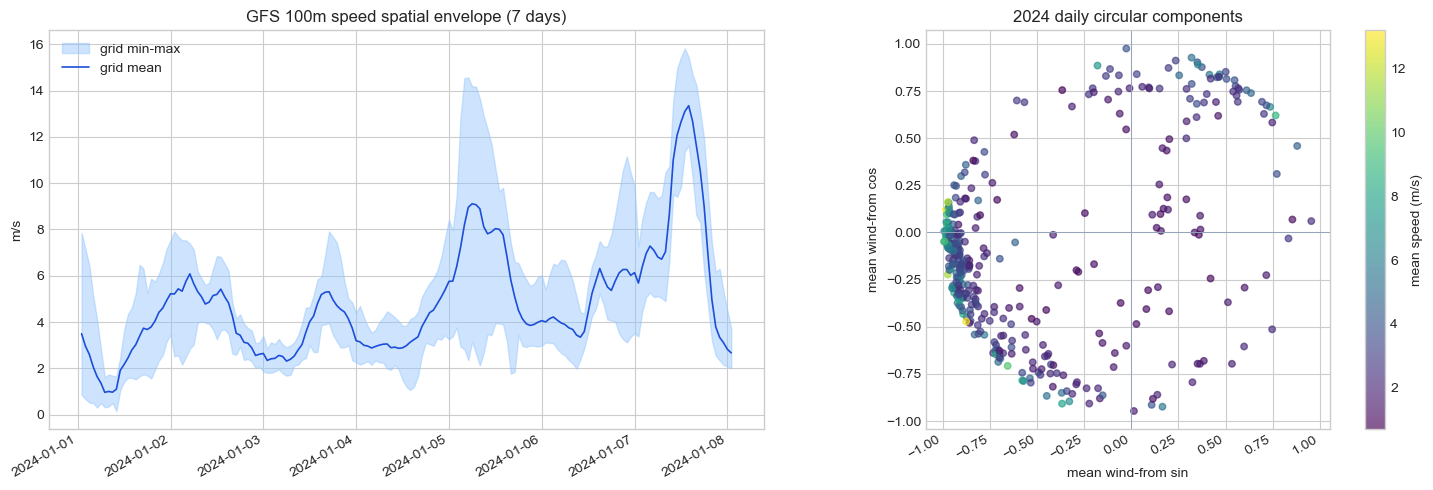

In [6]:
plotStart = pd.Timestamp("2024-01-01 01:00:00")
plotEnd = plotStart + pd.Timedelta(days=7)
plotMask = vectorPair.train["forecast_kst_dtm"].between(plotStart, plotEnd)
plotFrame = vectorPair.train.loc[plotMask]
prefix = "gfs_windvec_100m"
directionSample = vectorPair.train.loc[
  vectorPair.train["forecast_kst_dtm"].dt.year.eq(2024)
].iloc[::24]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].fill_between(
  plotFrame["forecast_kst_dtm"],
  plotFrame[f"{prefix}_speed_min"],
  plotFrame[f"{prefix}_speed_max"],
  color="#93c5fd",
  alpha=0.45,
  label="grid min-max",
)
axes[0].plot(
  plotFrame["forecast_kst_dtm"],
  plotFrame[f"{prefix}_speed_mean"],
  color="#1d4ed8",
  linewidth=1.2,
  label="grid mean",
)
axes[0].set_title("GFS 100m speed spatial envelope (7 days)")
axes[0].set_ylabel("m/s")
axes[0].legend()
scatter = axes[1].scatter(
  directionSample[f"{prefix}_from_sin_mean"],
  directionSample[f"{prefix}_from_cos_mean"],
  c=directionSample[f"{prefix}_speed_mean"],
  cmap="viridis",
  alpha=0.65,
  s=22,
)
axes[1].axhline(0, color="#94a3b8", linewidth=0.7)
axes[1].axvline(0, color="#94a3b8", linewidth=0.7)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("mean wind-from sin")
axes[1].set_ylabel("mean wind-from cos")
axes[1].set_title("2024 daily circular components")
fig.colorbar(scatter, ax=axes[1], label="mean speed (m/s)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 관찰 → 해석 → 다음 판단

관찰: 100m speed envelope 폭과 중심은 시간에 따라 함께 변하고, mean wind-from 좌표는 원 둘레와 내부를 모두 이동한다.  
해석: grid 풍속 범위와 방향 집중도는 상수가 아니며 원시 U/V의 단순 이름 변경이 아니다. 다만 시각적 분리는 예측 성능을 보장하지 않는다.  
다음 판단: 동일 모델·seed·mask·metric·clip 조건에서 48개 추가 피처의 순효과를 측정한다.

## 5단계. 해석과 의사결정: 동일 조건 2024 holdout

| 계약 | 고정값 |
|---|---|
| split | 달력 연도 <2024 train, ==2024 holdout; 2025-01-01 00 경계 1행 제외 |
| model/seed | 공식 RandomForest, random_state=42 |
| mask | target별 non-null train, 공식 actual ≥ 10% capacity 평가 |
| imputer | feature set별 train slice fit, validation/test transform only |
| metric | total_score, 1-NMAE, FICR, target NMAE/FICR, 6%/8% 안착률 |
| clipping | actual 원본 유지, prediction만 0~capacity |

In [7]:
validActualOriginal = trainLabels.loc[
  holdoutMask, TARGET_COLS
].copy(deep=True)
actualHashBefore = hashlib.sha256(
  pd.util.hash_pandas_object(
    validActualOriginal, index=True
  ).to_numpy().tobytes()
).hexdigest()
featureSets = {
  "expanded_spatial": expandedX,
  "expanded_plus_vector": vectorX,
}
modelBundles = {}
validationPredictions = {}
overallRows = []
for featureSet, fullX in featureSets.items():
  started = time.perf_counter()
  bundle = train_random_forest_baseline(
    fullX.loc[modelTrainMask],
    trainLabels.loc[modelTrainMask],
    model_params=dict(OFFICIAL_RF_PARAMS),
  )
  assert np.array_equal(
    imputerObjects[featureSet].statistics_,
    bundle.imputer.statistics_,
    equal_nan=True,
  )
  predictions = predict_random_forest_baseline(
    bundle, fullX.loc[holdoutMask]
  )
  totalScore, oneMinusNmae, ficr = metric(
    validActualOriginal, predictions
  )
  modelBundles[featureSet] = bundle
  validationPredictions[featureSet] = predictions
  overallRows.append({
    "feature_set": featureSet,
    "feature_count": fullX.shape[1],
    "train_rows": int(modelTrainMask.sum()),
    "holdout_rows": int(holdoutMask.sum()),
    "total_score": float(totalScore),
    "one_minus_nmae": float(oneMinusNmae),
    "ficr": float(ficr),
    "fit_predict_seconds": time.perf_counter() - started,
  })
actualHashAfter = hashlib.sha256(
  pd.util.hash_pandas_object(
    validActualOriginal, index=True
  ).to_numpy().tobytes()
).hexdigest()
assert actualHashBefore == actualHashAfter
assert all(
  bundle.train_rows[target]
  == int(trainLabels.loc[modelTrainMask, target].notna().sum())
  for bundle in modelBundles.values()
  for target in TARGET_COLS
)
overallScoreboard = pd.DataFrame(overallRows).set_index("feature_set")
display(overallScoreboard)
display(pd.DataFrame({
  name: bundle.train_rows for name, bundle in modelBundles.items()
}))
print({"actual_unchanged": actualHashBefore == actualHashAfter})

,feature_count,train_rows,holdout_rows,total_score,one_minus_nmae,ficr,fit_predict_seconds
feature_set,,,,,,,
expanded_spatial,271,17519,8784,0.585265,0.867325,0.303204,5.326433
expanded_plus_vector,319,17519,8784,0.586482,0.867895,0.305070,6.546868


,expanded_spatial,expanded_plus_vector
kpx_group_1,17421,17421
kpx_group_2,17422,17422
kpx_group_3,8759,8759


{'actual_unchanged': True}


### 관찰 → 해석 → 다음 판단

두 실험은 같은 17,519개 학습 시간축, target별 non-null mask, 공식 RF 파라미터와 8,784시간 holdout을 사용한다. 감사용 imputer와 실제 bundle의 median 통계가 같고 actual hash도 학습·예측 전후 동일하다. 따라서 성능 차이는 48개 wind vector 파생의 추가 효과로 해석한다.

In [8]:
def targetScoreRows(featureSet, actualFrame, predictionFrame):
  rows = []
  for target in TARGET_COLS:
    capacity = CAPACITY_KWH[target]
    actual = actualFrame[target].to_numpy(dtype=float)
    prediction = predictionFrame[target].to_numpy(dtype=float)
    valid = np.isfinite(actual) & (actual >= capacity * 0.10)
    errorRate = np.abs(prediction[valid] - actual[valid]) / capacity
    unitPrice = np.select(
      [errorRate <= 0.06, errorRate <= 0.08],
      [4.0, 3.0],
      default=0.0,
    )
    rows.append({
      "feature_set": featureSet,
      "target": target,
      "metric_rows": int(valid.sum()),
      "nmae": float(errorRate.mean()),
      "ficr": float(
        np.sum(actual[valid] * unitPrice)
        / np.sum(actual[valid] * 4.0)
      ),
      "landing_6pct": float((errorRate <= 0.06).mean()),
      "landing_8pct": float((errorRate <= 0.08).mean()),
    })
  return rows

targetScoreboard = pd.DataFrame([
  row
  for featureSet, predictions in validationPredictions.items()
  for row in targetScoreRows(
    featureSet, validActualOriginal, predictions
  )
])
metricColumns = ["total_score", "one_minus_nmae", "ficr"]
overallDelta = (
  overallScoreboard.loc["expanded_plus_vector", metricColumns]
  - overallScoreboard.loc["expanded_spatial", metricColumns]
).rename("vector_minus_expanded")
targetNmae = targetScoreboard.pivot(
  index="target", columns="feature_set", values="nmae"
)
improvedTargetCount = int(
  (
    targetNmae["expanded_plus_vector"]
    < targetNmae["expanded_spatial"]
  ).sum()
)
totalDelta = float(overallDelta["total_score"])
if (
  totalDelta > 0
  and improvedTargetCount >= 2
  and overallDelta["one_minus_nmae"] >= 0
  and overallDelta["ficr"] >= 0
):
  decisionStatus = "채택"
elif totalDelta > 0 and improvedTargetCount >= 2:
  decisionStatus = "조건부 채택"
else:
  decisionStatus = "보류"
display(overallDelta.to_frame())
display(targetScoreboard)
print({
  "decision": decisionStatus,
  "total_score_delta": totalDelta,
  "targets_with_lower_nmae": improvedTargetCount,
})

,vector_minus_expanded
total_score,0.001218
one_minus_nmae,0.000569
ficr,0.001866


,feature_set,target,metric_rows,nmae,ficr,landing_6pct,landing_8pct
0,expanded_spatial,kpx_group_1,4989,0.126971,0.282609,0.286631,0.380437
1,expanded_spatial,kpx_group_2,4976,0.124087,0.373646,0.323955,0.422830
2,expanded_spatial,kpx_group_3,4566,0.146965,0.253357,0.268287,0.360053
3,expanded_plus_vector,kpx_group_1,4989,0.126590,0.284206,0.285628,0.381840
4,expanded_plus_vector,kpx_group_2,4976,0.124307,0.373853,0.321141,0.422428
5,expanded_plus_vector,kpx_group_3,4566,0.145419,0.257152,0.276610,0.364871


{'decision': '채택', 'total_score_delta': 0.001217752625434776, 'targets_with_lower_nmae': 2}


### 관찰 → 해석 → 다음 판단

관찰: expanded 대비 vector 추가안은 total score 0.585265 → 0.586482(+0.001218), 1-NMAE 0.867325 → 0.867895(+0.000569), FICR 0.303204 → 0.305070(+0.001866)으로 세 전체 지표가 모두 개선됐다. Group 1 NMAE는 0.126971 → 0.126590, Group 3은 0.146965 → 0.145419로 감소했지만 Group 2는 0.124087 → 0.124307(+0.000220)로 소폭 악화됐다. 8% 안착률은 Group 1·3에서 상승하고 Group 2에서 0.000402 하락했다.  
해석: wind vector는 전체 오차와 정산 지표를 함께 개선하고 3개 target 중 2개를 개선해 사전 채택 기준을 충족한다. 다만 개선폭은 작고 Group 2의 NMAE·6%·8% 안착률 퇴행이 있어 모든 target에 보편적인 이득으로 해석하지 않는다.  
다음 판단: 네 primary pair를 expanded 기준선에 채택하되 Group 2 회귀를 모니터링하고, 상층 pair는 이번 결론에 섞지 않는다.

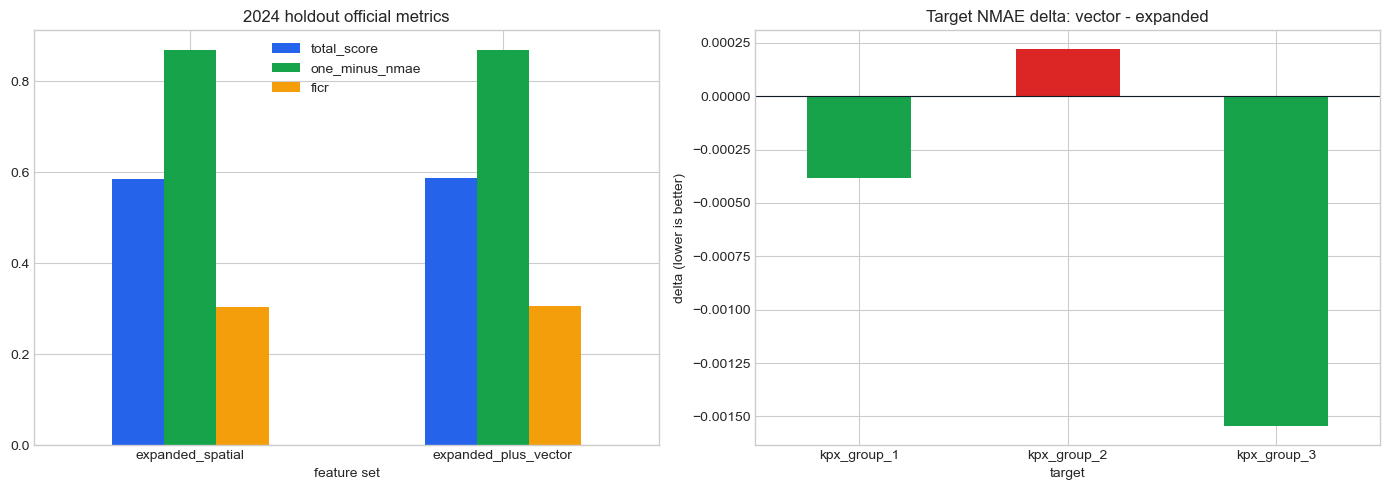

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
overallScoreboard[[
  "total_score", "one_minus_nmae", "ficr"
]].plot.bar(
  ax=axes[0],
  color=["#2563eb", "#16a34a", "#f59e0b"],
)
axes[0].set_title("2024 holdout official metrics")
axes[0].set_xlabel("feature set")
axes[0].tick_params(axis="x", rotation=0)
targetNmaeDelta = (
  targetNmae["expanded_plus_vector"]
  - targetNmae["expanded_spatial"]
)
targetNmaeDelta.plot.bar(
  ax=axes[1],
  color=["#16a34a" if value < 0 else "#dc2626" for value in targetNmaeDelta],
)
axes[1].axhline(0, color="#111827", linewidth=0.8)
axes[1].set_title("Target NMAE delta: vector - expanded")
axes[1].set_xlabel("target")
axes[1].set_ylabel("delta (lower is better)")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 실패 사례와 강건성 해석

| 실패·위험 | 방어 또는 해석 |
|---|---|
| U/V 누락·dtype·이름·threshold 오류 | 18개 RED→GREEN으로 fail closed |
| sqrt(mean U²+mean V²) 상쇄 | grid별 speed 파생 후 공간 집계 |
| calm과 북풍 혼동 | speed≤1e-6일 때 방향만 NaN |
| component 결측 은폐 | speed·sin·cos 모두 NaN 전파 |
| 5m stress를 풍속으로 오독 | KMA 단위 N/m² 확인 후 whitelist 제외 |
| 50m 성분 극값을 동시 벡터로 오독 | core pair에서 제외 |
| LDAPS 좌표 회전 불명 | speed는 불변, 방향은 true-north로 단정하지 않음 |
| 기존 U/V 통계와 파생 중복 | 성능·비용을 함께 판단 |
| 단일 RF·2024 holdout | 최종 모델 확정이 아닌 feature lab 증거 |

In [10]:
validationCommands = [
  (
    "focused_pytest",
    [
      sys.executable,
      "-m",
      "pytest",
      "tests/test_wind_vector_features.py",
      "-q",
    ],
  ),
  ("full_pytest", [sys.executable, "-m", "pytest", "-q"]),
  (
    "notebook_integrity",
    [sys.executable, "scripts/check_notebook_integrity.py"],
  ),
]
validationRows = []
for checkName, command in validationCommands:
  completed = subprocess.run(
    command,
    cwd=PROJECT_ROOT,
    capture_output=True,
    env={
      **os.environ,
      "PYTHONIOENCODING": "utf-8",
      "PYTHONUTF8": "1",
    },
    text=True,
    encoding="utf-8",
    errors="replace",
    timeout=1800,
    check=False,
  )
  combinedOutput = (
    (completed.stdout or "") + (completed.stderr or "")
  ).strip().splitlines()
  validationRows.append({
    "check": checkName,
    "returncode": completed.returncode,
    "last_line": combinedOutput[-1] if combinedOutput else "",
  })
validationResults = pd.DataFrame(validationRows)
artifactFilesAfter = snapshotArtifactFiles()
guardedArtifactsAfter = snapshotGuardedArtifacts()
newGuardedArtifacts = sorted(
  set(guardedArtifactsAfter) - set(guardedArtifactsBefore)
)
filesWritten = (
  artifactFilesAfter != artifactFilesBefore
  or bool(newGuardedArtifacts)
)
memoryContract = pd.DataFrame([
  {
    "feature_set": featureSet,
    "models_in_memory": sorted(bundle.models),
    "schema_sha256": schemaSha256(bundle.feature_columns),
    "registry_csv_written": any(
      "registry" in path.lower() and path.lower().endswith(".csv")
      for path in newGuardedArtifacts
    ),
    "model_file_written": any(
      path.lower().endswith((".pkl", ".pickle", ".joblib"))
      for path in newGuardedArtifacts
    ),
    "submission_csv_written": any(
      "submission" in path.lower() and path.lower().endswith(".csv")
      for path in newGuardedArtifacts
    ),
  }
  for featureSet, bundle in modelBundles.items()
])
display(validationResults)
display(memoryContract)
print({
  "artifact_files_before": artifactFilesBefore,
  "artifact_files_after": artifactFilesAfter,
  "new_guarded_artifacts": newGuardedArtifacts,
  "files_written": filesWritten,
})

,check,returncode,last_line
0,focused_pytest,0,[32m[32m[1m18 passed[0m[32m in 2.46s[0m[0m
1,full_pytest,0,[32m[32m[1m79 passed[0m[32m in 11.16s[0m...
2,notebook_integrity,0,노트북 무결성 검사 통과: 8개


,feature_set,models_in_memory,schema_sha256,registry_csv_written,model_file_written,submission_csv_written
0,expanded_spatial,"[kpx_group_1, kpx_group_2, kpx_group_3]",5b0331b62b8e88562ed7a1b5505043b1d41edffafb2104...,False,False,False
1,expanded_plus_vector,"[kpx_group_1, kpx_group_2, kpx_group_3]",f5f3b9eb20fabffedf47eac1e95202df8ff1d14d0be5f4...,False,False,False


{'artifact_files_before': [], 'artifact_files_after': [], 'new_guarded_artifacts': [], 'files_written': False}


## Final Decision Box

| 결정 항목 | 실행 증거 | 판단 |
|---|---|---|
| 입력 물리성 | LDAPS 10m, GFS 10/80/100m만 사용 | stress·성분 극값 제외 |
| schema | 271 → 319, train/test exact | 추가 48개 |
| 전처리 | test 결측 188 유지 후 train median으로 0 | leakage·은폐 없음 |
| 2024 holdout | total 0.585265 → 0.586482; 1-NMAE +0.000569; FICR +0.001866 | 세 전체 지표 개선 |
| target NMAE | G1 -0.000381, G2 +0.000220, G3 -0.001546 | 3개 중 2개 개선, G2 퇴행 명시 |
| 6%/8% 안착 | G1 8% 상승, G3 두 임계값 상승, G2 두 임계값 하락 | FICR 전체는 개선하나 균일하지 않음 |
| 안전 | actual hash 불변, 메모리 모델만 | 파일 생성 없음 |
| 검증 | focused 18, full 79, 노트북 8개 재검증 | GREEN |

**최종 결정: 채택.** expanded spatial에 LDAPS 10m와 GFS 10/80/100m grid별 speed·wind-from sin/cos의 네 공간 통계를 추가한다. 전체 세 지표와 3개 중 2개 target NMAE가 개선됐기 때문이다. 단, Group 2 소폭 퇴행과 LDAPS 방향 좌표계 한계를 명시하고 공식 mean 및 기존 expanded를 통제군으로 유지한다.

## 다음 판단

| 우선순위 | 후보 | 다음 검증 질문 |
|---:|---|---|
| 1 | turbine 좌표 nearest/IDW pooling | 모든 grid 동등 평균보다 발전단지 인접 격자가 유리한가 |
| 2 | GFS PBL·850/700/500hPa vector ablation | 상층 바람 문맥이 허브 높이 피처를 보완하는가 |
| 3 | 계절 fold와 GBM 민감도 | RF 한 모델·단일 holdout 결론이 유지되는가 |

후속 후보는 시작하지 않는다. R3에 따라 Wind Vector Feature Lab 한 작업을 완료한 뒤 정지한다.